In [7]:
import sys
import logging
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# User defined modules
E9path = Path("C:/", "Users", "ken92", "Documents", "Studies", "E5", "simulation", "E9_simulations")
if str(E9path) not in sys.path:
    sys.path.insert(1, str(E9path))
from E9_fn import util
import E9_fn.E9_models as E9M

In [16]:
# Load the pre-calculated orbital energies, and get some basic values from it
# file_name = Path("kagome_lat20x20_sys12x12_Vrsv-2p0000", "np_arrays.npz")
file_name = Path("kagome_lat20x20_sys12x12_Vrsv-4p5000", "np_arrays.npz")
file_path = Path(E9path, "projects", "flat_band_cooling", "eigvals_library", "kagome", file_name)
loaded_file = np.load(file_path)
E_orbs_exp = loaded_file["eigvals"]
d_sys_exp = loaded_file["density_sys"]
n_orbs = len(E_orbs_exp)
# n_sys = loaded_file["n_sys"]
n_sys = 12**2 * 3
n_rsv = n_orbs - n_sys
E_range = (E_orbs_exp[0], E_orbs_exp[-1])

sp_name = "fermi1"
name_sr1 = sp_name
sr_list = [E9M.muVT_subregion(name_sr1, sp_name, n_orbs, +1, None, E_range, [], E_orbs_exp)]
#%% Calculation
# mu_scan = np.linspace(-0.5, 0.5, 101)
mu_scan = np.linspace(-3., -2., 101)
T_scan = np.linspace(0.01, 0.5, 50)
exp_list = [[None for _ in mu_scan] for _ in T_scan]
s_list = np.zeros_like(exp_list, dtype = float)
N_list = np.zeros_like(exp_list, dtype = float)
nu_rsv_list = np.zeros_like(exp_list, dtype = float)
for i, T in enumerate(T_scan):
    for j, mu in enumerate(mu_scan):
        exp_ij = E9M.muVT_exp(T, sr_list, {sp_name: mu})
        exp_list[i][j] = exp_ij
        s_list[i, j] = exp_ij.S / n_orbs
        N_list[i, j] = exp_ij.N_dict[sp_name]
        nu_rsv_list[i, j] = sum(util.fermi_stat(E_orbs_exp, T, mu) * (1 - d_sys_exp)) / n_rsv

n_list = N_list / n_orbs

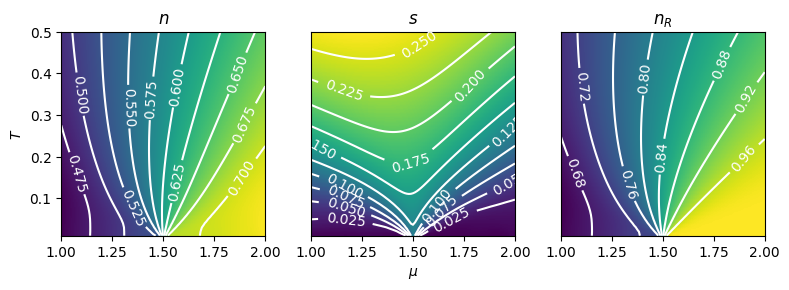

In [ ]:
fig, axes = plt.subplots(1, 3, figsize = (8, 3))
n_cntr = 10
x_axis = mu_scan + 4    # to shift the energy to match the thermodynamic case
for ttl, data, ax in zip([r"$n$", r"$s$", r"$n_R$"],
                         [n_list, s_list, nu_rsv_list],
                         axes):
    img = ax.imshow(data, aspect = (x_axis[-1] - x_axis[0]) / (T_scan[-1] - T_scan[0]),
              extent = [x_axis[0], x_axis[-1], T_scan[0], T_scan[-1]], origin = "lower")
    ax.set_title(ttl)
    cntr = ax.contour(x_axis, T_scan, data, colors = "white", levels = n_cntr)
    ax.clabel(cntr, inline = True)
    # plt.colorbar(mappable = img, ax = ax)
axes[1].set_xlabel(r"$\mu$")
axes[0].set_ylabel(r"$T$")
axes[1].set_yticks([])
axes[2].set_yticks([])
fig.tight_layout()

thesis_fig_path = Path(r"C:\Users\ken92\Documents\Studies\E5\Theses\figures\flatband")
file_full_path = Path(thesis_fig_path, "finite_tb_EoS_Vrsv-4.5.pdf")
# fig.savefig(file_full_path, facecolor = "none", dpi = 300, bbox_inches='tight')